# Kasus 2 — Digit Recognizer (MNIST)

**UTS Pengantar Deep Learning** — Multi-class classification 10 kelas digit (0–9) dari gambar 28×28 grayscale.

Bandingkan **classical** (HOG+SVM, PCA+KNN) vs **deep learning** (CNN). Dataset Kaggle (`mnist_dataset/train.csv` 42k berlabel + `test.csv` 28k tanpa label untuk submission). Karena test.csv tidak punya label (resmi Kaggle), evaluasi internal pakai split val dari train.csv.

## 1. Setup & Imports

In [1]:
import os, sys, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skimage.feature import hog

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
warnings.filterwarnings('ignore')

DATA_DIR = 'mnist_dataset'
print('torch :', torch.__version__)
print('numpy :', np.__version__)
print('pandas:', pd.__version__)

torch : 2.4.1+cpu
numpy : 1.26.4
pandas: 3.0.2


## 2. Load Data

Format Kaggle digit-recognizer:
- `train.csv`: 42000 baris, kolom `label` + 784 piksel (`pixel0`..`pixel783`).
- `test.csv`: 28000 baris, hanya 784 piksel (tanpa label — untuk submission Kaggle).

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print('train.csv:', train_df.shape)
print('test.csv :', test_df.shape)
train_df.head()

train.csv: (42000, 785)
test.csv : (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
X_train_full = train_df.drop(columns='label').values.astype(np.uint8)   # (42000, 784)
y_train_full = train_df['label'].values.astype(np.int64)
X_kaggle     = test_df.values.astype(np.uint8)                           # (28000, 784) — submission only

print('train: X', X_train_full.shape, '| y', y_train_full.shape, '| range:', X_train_full.min(), '-', X_train_full.max())
print('kaggle test (predict only):', X_kaggle.shape)
print('\nDistribusi kelas (train):')
print(pd.Series(y_train_full).value_counts().sort_index().to_string())

train: X (42000, 784) | y (42000,) | range: 0 - 255
kaggle test (predict only): (28000, 784)

Distribusi kelas (train):
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188


## 3. EDA

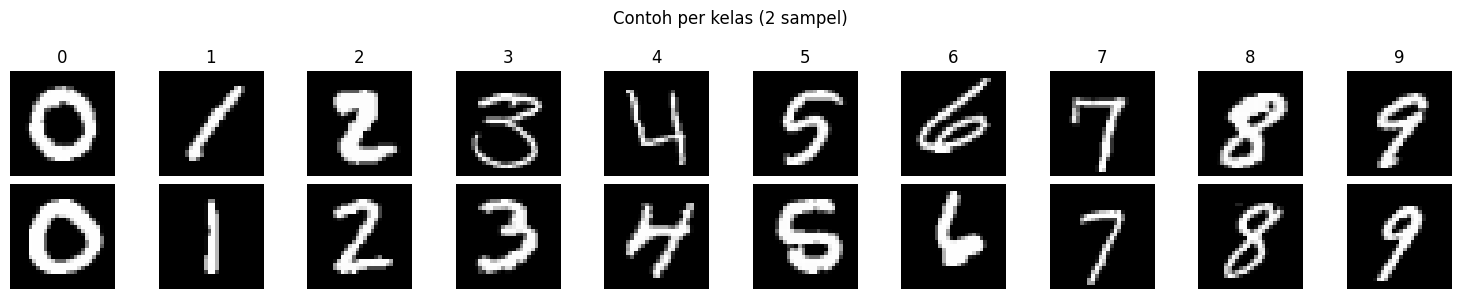

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for cls in range(10):
    idxs = np.where(y_train_full == cls)[0][:2]
    for r, idx in enumerate(idxs):
        axes[r, cls].imshow(X_train_full[idx].reshape(28, 28), cmap='gray')
        axes[r, cls].axis('off')
        if r == 0: axes[r, cls].set_title(str(cls))
plt.suptitle('Contoh per kelas (2 sampel)')
plt.tight_layout(); plt.show()

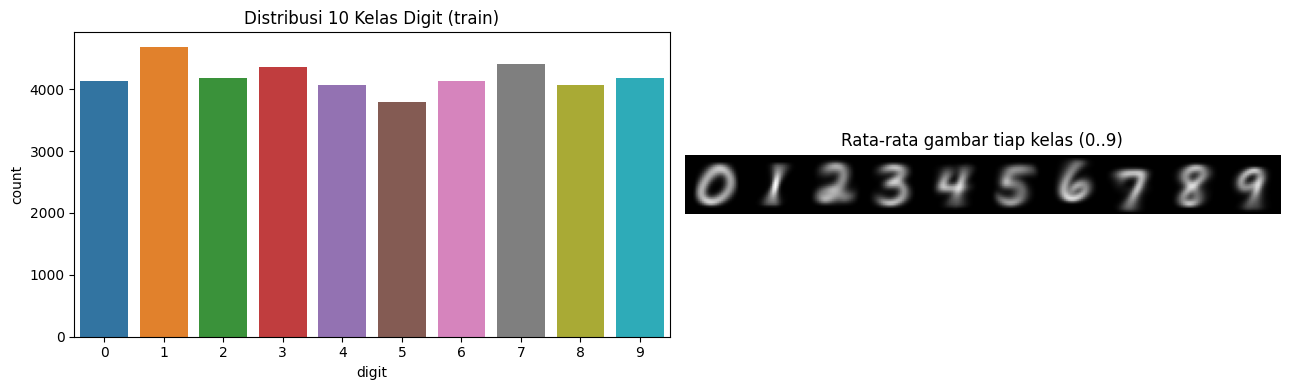

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x=y_train_full, ax=axes[0], palette='tab10')
axes[0].set_title('Distribusi 10 Kelas Digit (train)')
axes[0].set_xlabel('digit'); axes[0].set_ylabel('count')

mean_per_class = np.stack([X_train_full[y_train_full==c].mean(axis=0).reshape(28,28) for c in range(10)])
axes[1].imshow(np.hstack(mean_per_class), cmap='gray')
axes[1].set_title('Rata-rata gambar tiap kelas (0..9)')
axes[1].axis('off')
plt.tight_layout(); plt.show()

Insight singkat:
- 10 kelas relatif balanced (~4200/kelas).
- Gambar 28×28 grayscale, range 0–255.
- Rata-rata kelas "1" tipis & vertikal, sementara "0" "8" punya pola bulat. Ini sinyal yang bisa ditangkap HOG. Tapi digit yang tulisan tangannya bervariasi (mis. "3" vs "5", "4" vs "9") biasanya jadi tempat error utama.

## 4. Preprocessing & Split

Mengikuti split Kaggle apa adanya — tidak ada pemisahan train/test buatan:
1. **train.csv (42k)** → split jadi **train + val (90/10) stratified** untuk hyperparameter tuning & evaluasi.
2. **test.csv (28k)** → khusus prediksi submission (tidak ada label).
3. Untuk classical (HOG+SVM, PCA+KNN), training di-subsample ke 20000 sampel agar feasibel di CPU. CNN pakai full train. Catatan: ukuran val sama untuk semua model — perbandingan tetap fair.
4. Normalisasi piksel ke [0, 1]. CNN butuh shape `(N,1,28,28)`.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, stratify=y_train_full, random_state=SEED)
print(f'Train (untuk CNN)        : {X_train.shape}')
print(f'Val                      : {X_val.shape}')
print(f'Kaggle test (predict only): {X_kaggle.shape}')

# Subsample 20k khusus classical (HOG+SVM, PCA+KNN)
idx_sub, _ = train_test_split(np.arange(len(X_train)), train_size=20000,
                                stratify=y_train, random_state=SEED)
X_train_cls = X_train[idx_sub]; y_train_cls = y_train[idx_sub]
print(f'Train (classical)        : {X_train_cls.shape} (subsample dari train CNN)')

# Normalisasi & reshape
X_train_n     = X_train.astype(np.float32) / 255.0
X_train_cls_n = X_train_cls.astype(np.float32) / 255.0
X_val_n       = X_val.astype(np.float32)   / 255.0
X_kaggle_n    = X_kaggle.astype(np.float32) / 255.0

X_train_img     = X_train_n.reshape(-1, 28, 28)
X_train_cls_img = X_train_cls_n.reshape(-1, 28, 28)
X_val_img       = X_val_n.reshape(-1, 28, 28)
X_kaggle_img    = X_kaggle_n.reshape(-1, 28, 28)

results = {}

Train (untuk CNN)        : (37800, 784)
Val                      : (4200, 784)
Kaggle test (predict only): (28000, 784)
Train (classical)        : (20000, 784) (subsample dari train CNN)


## 5. Baseline Konvensional

### 5a. HOG + Linear SVM

**HOG** (Histogram of Oriented Gradients) menangkap distribusi arah edge dalam blok-blok kecil — baik untuk membedakan bentuk digit. Hasilnya vector fitur dimensi rendah, lalu dikasih ke **LinearSVC**.

Parameter HOG: 8 orientasi, cell 7×7, blok 2×2 cell — pas untuk image 28×28. Output ~288 fitur per gambar. Hyperparameter SVM `C` dituning manual lewat val set.

In [7]:
def extract_hog(images):
    feats = []
    for img in images:
        f = hog(img, orientations=8, pixels_per_cell=(7, 7),
                cells_per_block=(2, 2), block_norm='L2-Hys')
        feats.append(f)
    return np.stack(feats).astype(np.float32)

t0 = time.time()
Hog_train  = extract_hog(X_train_cls_img)
Hog_val    = extract_hog(X_val_img)
Hog_kaggle = extract_hog(X_kaggle_img)
hog_extract_time = time.time() - t0
print(f'HOG feature dim: {Hog_train.shape[1]}  | extract time: {hog_extract_time:.1f}s')

# Tuning C cepat lewat val
best_C, best_val_acc = None, -1
for C in [0.1, 1.0, 5.0]:
    clf = LinearSVC(C=C, max_iter=3000, random_state=SEED)
    clf.fit(Hog_train, y_train_cls)
    va = accuracy_score(y_val, clf.predict(Hog_val))
    print(f'  C={C}: val_acc={va:.4f}')
    if va > best_val_acc:
        best_C, best_val_acc = C, va

t0 = time.time()
svm = LinearSVC(C=best_C, max_iter=3000, random_state=SEED)
svm.fit(Hog_train, y_train_cls)
svm_train_time = time.time() - t0

t0 = time.time()
svm_val_pred = svm.predict(Hog_val)
svm_infer_time = time.time() - t0

svm_val_acc = accuracy_score(y_val, svm_val_pred)
print(f'\nbest C       : {best_C}')
print(f'val acc      : {svm_val_acc:.4f}')
print(f'train time   : {svm_train_time:.2f}s (+ HOG extract {hog_extract_time:.1f}s)')
print(f'infer time   : {svm_infer_time:.3f}s untuk {len(y_val)} sampel val')

results['HOG+SVM'] = dict(val=svm_val_acc,
                           train_time=svm_train_time + hog_extract_time,
                           infer_time=svm_infer_time, pred_val=svm_val_pred,
                           model=svm, hog_kaggle=Hog_kaggle)

HOG feature dim: 288  | extract time: 10.5s


  C=0.1: val_acc=0.9588


  C=1.0: val_acc=0.9650


  C=5.0: val_acc=0.9676



best C       : 5.0
val acc      : 0.9676
train time   : 3.55s (+ HOG extract 10.5s)
infer time   : 0.004s untuk 4200 sampel val


### 5b. PCA + KNN

**PCA** untuk reduksi dimensi (784 → 50 komponen) supaya KNN tidak terjebak di curse of dimensionality. **KNN** dengan k dituning lewat val. Dipilih kombinasi ini sebagai kontras dari HOG+SVM (linear model dengan fitur tangan-buatan vs lazy learner dengan reduksi dimensi statistik).

In [8]:
t0 = time.time()
pca = PCA(n_components=50, random_state=SEED)
PC_train  = pca.fit_transform(X_train_cls_n)
PC_val    = pca.transform(X_val_n)
PC_kaggle = pca.transform(X_kaggle_n)
pca_time = time.time() - t0
print(f'Variance retained dengan 50 PC: {pca.explained_variance_ratio_.sum():.4f}')
print(f'PCA fit+transform time         : {pca_time:.2f}s')

best_k, best_val_acc = None, -1
for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(PC_train, y_train_cls)
    va = accuracy_score(y_val, knn.predict(PC_val))
    print(f'  k={k}: val_acc={va:.4f}')
    if va > best_val_acc:
        best_k, best_val_acc = k, va

t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(PC_train, y_train_cls)
knn_train_time = time.time() - t0

t0 = time.time()
knn_val_pred = knn.predict(PC_val)
knn_infer_time = time.time() - t0

knn_val_acc = accuracy_score(y_val, knn_val_pred)
print(f'\nbest k     : {best_k}')
print(f'val acc    : {knn_val_acc:.4f}')
print(f'train time : {knn_train_time:.2f}s (+ PCA {pca_time:.2f}s)')
print(f'infer time : {knn_infer_time:.3f}s untuk {len(y_val)} sampel val')

results['PCA+KNN'] = dict(val=knn_val_acc,
                           train_time=knn_train_time + pca_time,
                           infer_time=knn_infer_time, pred_val=knn_val_pred,
                           model=knn, pc_kaggle=PC_kaggle)

Variance retained dengan 50 PC: 0.8260
PCA fit+transform time         : 0.50s


  k=1: val_acc=0.9664
  k=3: val_acc=0.9674


  k=5: val_acc=0.9636

best k     : 3
val acc    : 0.9674
train time : 0.00s (+ PCA 0.50s)
infer time : 0.171s untuk 4200 sampel val


## 6. Deep Learning — CNN

**Justifikasi**: image 28×28 punya struktur spasial 2D yang kuat. CNN dengan filter konvolusi langsung memproses pola lokal (edge, sudut, lengkung) lalu kombinasi spasial — match dengan sifat data. MLP (flatten ke 784) akan kehilangan informasi spasial; HOG menangkapnya secara manual tapi terbatas. CNN belajar fitur yang lebih ekspresif secara end-to-end.

Arsitektur (sengaja dijaga simpel — bukan ResNet):
```
Conv(1→32, 3×3) → BN → ReLU → MaxPool(2)
Conv(32→64, 3×3) → BN → ReLU → MaxPool(2)
Flatten → Linear(64*7*7 → 128) → ReLU → Dropout(0.4) → Linear(128 → 10)
```

In [9]:
Xtr_t = torch.tensor(X_train_img[:,None,:,:],  dtype=torch.float32)
Xva_t = torch.tensor(X_val_img[:,None,:,:],    dtype=torch.float32)
Xkg_t = torch.tensor(X_kaggle_img[:,None,:,:], dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.long)
yva_t = torch.tensor(y_val,   dtype=torch.long)

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=128, shuffle=True)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.head(self.conv(x))

torch.manual_seed(SEED)
cnn = CNN()
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
ce  = nn.CrossEntropyLoss()
n_params_cnn = sum(p.numel() for p in cnn.parameters())
print(f'#parameters CNN: {n_params_cnn:,}')

#parameters CNN: 421,834


ep 1 | tr_loss 0.2431 acc 0.924 | va_loss 0.0650 acc 0.981


ep 2 | tr_loss 0.0812 acc 0.975 | va_loss 0.0543 acc 0.983


ep 3 | tr_loss 0.0679 acc 0.979 | va_loss 0.0473 acc 0.986


ep 4 | tr_loss 0.0511 acc 0.984 | va_loss 0.0485 acc 0.986


ep 5 | tr_loss 0.0467 acc 0.986 | va_loss 0.0475 acc 0.987


ep 6 | tr_loss 0.0388 acc 0.987 | va_loss 0.0406 acc 0.989


ep 7 | tr_loss 0.0360 acc 0.989 | va_loss 0.0373 acc 0.989


ep 8 | tr_loss 0.0324 acc 0.990 | va_loss 0.0372 acc 0.988



CNN val acc: 0.9890
train time : 92.55s
infer time : 0.342s untuk 4200 sampel val


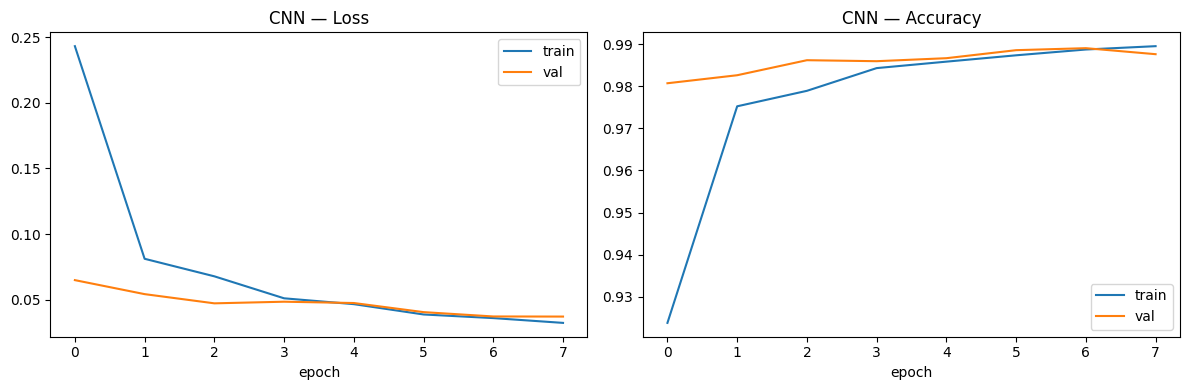

In [10]:
MAX_EPOCH = 8
PATIENCE  = 3
best_va, patience_left, best_state = -1, PATIENCE, None
hist = {'tr_loss':[], 'va_loss':[], 'tr_acc':[], 'va_acc':[]}

t0 = time.time()
for ep in range(1, MAX_EPOCH+1):
    cnn.train()
    losses, correct, total = [], 0, 0
    for xb, yb in train_loader:
        opt.zero_grad()
        logit = cnn(xb)
        l = ce(logit, yb); l.backward(); opt.step()
        losses.append(l.item())
        correct += (logit.argmax(1) == yb).sum().item(); total += yb.size(0)
    tr_loss = np.mean(losses); tr_acc = correct/total

    cnn.eval()
    with torch.no_grad():
        bs = 512; vL, vC, vT = [], 0, 0
        for i in range(0, len(Xva_t), bs):
            xb = Xva_t[i:i+bs]; yb = yva_t[i:i+bs]
            lg = cnn(xb)
            vL.append(ce(lg, yb).item() * yb.size(0))
            vC += (lg.argmax(1) == yb).sum().item(); vT += yb.size(0)
        va_loss = sum(vL) / vT; va_acc = vC / vT
    hist['tr_loss'].append(tr_loss); hist['va_loss'].append(va_loss)
    hist['tr_acc'].append(tr_acc);   hist['va_acc'].append(va_acc)
    print(f'ep {ep} | tr_loss {tr_loss:.4f} acc {tr_acc:.3f} | va_loss {va_loss:.4f} acc {va_acc:.3f}')

    if va_acc > best_va + 1e-4:
        best_va = va_acc; best_state = {k:v.clone() for k,v in cnn.state_dict().items()}
        patience_left = PATIENCE
    else:
        patience_left -= 1
    if patience_left <= 0:
        print(f'early stop @ ep {ep}'); break

cnn_train_time = time.time() - t0
cnn.load_state_dict(best_state)

cnn.eval()
t0 = time.time()
with torch.no_grad():
    cnn_pred_val = []
    bs = 512
    for i in range(0, len(Xva_t), bs):
        cnn_pred_val.append(cnn(Xva_t[i:i+bs]).argmax(1).numpy())
cnn_pred_val = np.concatenate(cnn_pred_val)
cnn_infer_time = time.time() - t0
cnn_val_acc = accuracy_score(y_val, cnn_pred_val)

print(f'\nCNN val acc: {cnn_val_acc:.4f}')
print(f'train time : {cnn_train_time:.2f}s')
print(f'infer time : {cnn_infer_time:.3f}s untuk {len(y_val)} sampel val')

results['CNN'] = dict(val=cnn_val_acc, train_time=cnn_train_time, infer_time=cnn_infer_time,
                      pred_val=cnn_pred_val, model=cnn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['tr_loss'], label='train'); axes[0].plot(hist['va_loss'], label='val')
axes[0].set_title('CNN — Loss'); axes[0].legend(); axes[0].set_xlabel('epoch')
axes[1].plot(hist['tr_acc'],  label='train'); axes[1].plot(hist['va_acc'],  label='val')
axes[1].set_title('CNN — Accuracy'); axes[1].legend(); axes[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

## 7. Perbandingan

  Model Val Acc Train (s) Infer (s)
HOG+SVM  0.9676     14.04     0.004
PCA+KNN  0.9674      0.50     0.171
    CNN  0.9890     92.55     0.342


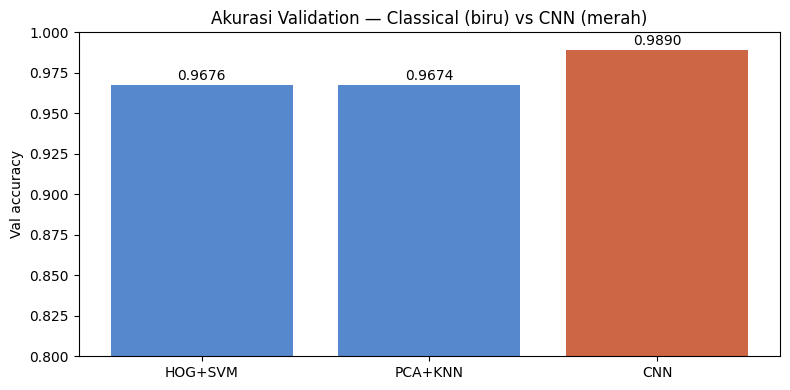

In [11]:
rows = []
for name, r in results.items():
    rows.append({
        'Model'      : name,
        'Val Acc'    : f"{r['val']:.4f}",
        'Train (s)'  : f"{r['train_time']:.2f}",
        'Infer (s)'  : f"{r['infer_time']:.3f}",
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
names = list(results.keys())
vals = [results[n]['val'] for n in names]
colors = ['#5588cc','#5588cc','#cc6644']
bars = ax.bar(names, vals, color=colors)
ax.set_ylabel('Val accuracy'); ax.set_ylim(0.8, 1.0)
ax.set_title('Akurasi Validation — Classical (biru) vs CNN (merah)')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 8. Confusion Matrix per Model (Val)

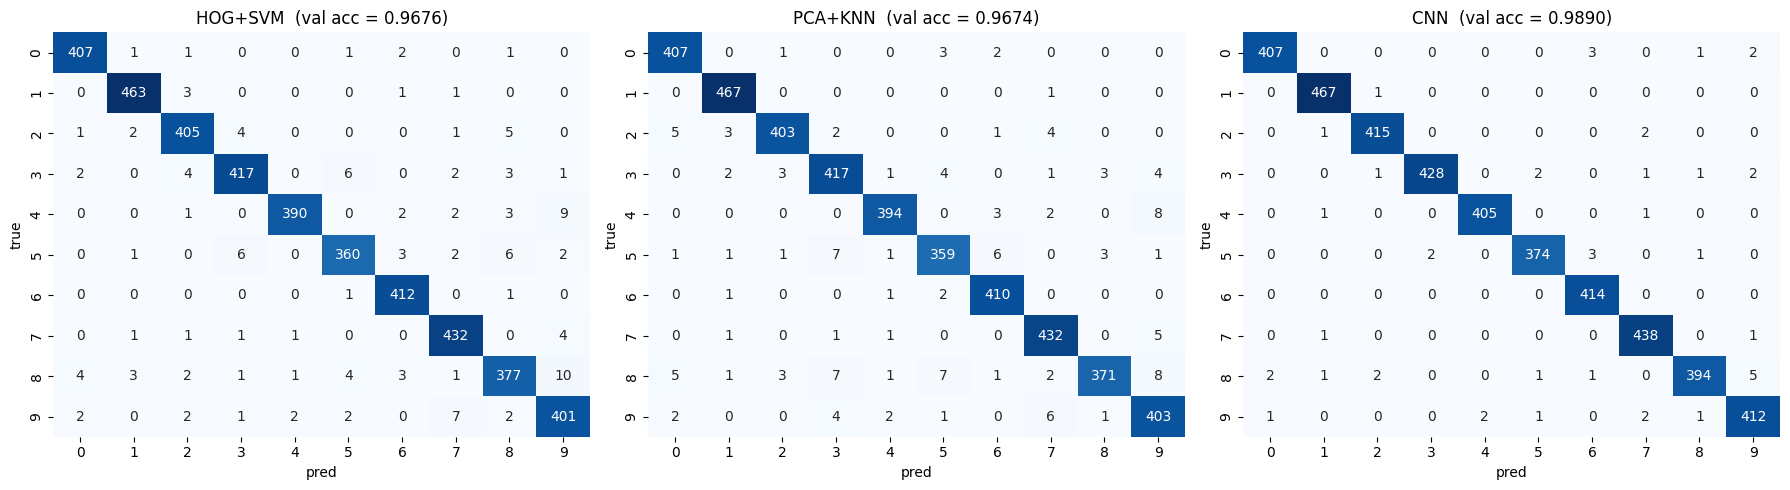

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, r['pred_val'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10), cbar=False)
    ax.set_title(f'{name}  (val acc = {r["val"]:.4f})')
    ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

## 9. Analisis Error

Apakah pola kesalahan HOG+SVM dan CNN berbeda? Tampilkan:
1. Sampel val yang salah di **HOG+SVM tapi benar di CNN** (kemenangan CNN).
2. Sampel val yang salah di **CNN tapi benar di HOG+SVM** (kasus DL kalah).
3. Sampel val yang **salah di kedua model** (kasus sulit).

salah hanya di HOG+SVM (CNN benar): 110
salah hanya di CNN (HOG+SVM benar): 20
salah di kedua model              : 26


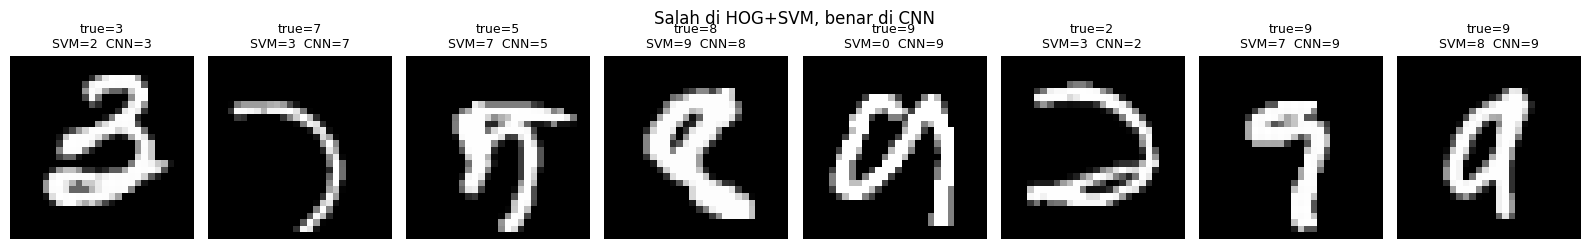

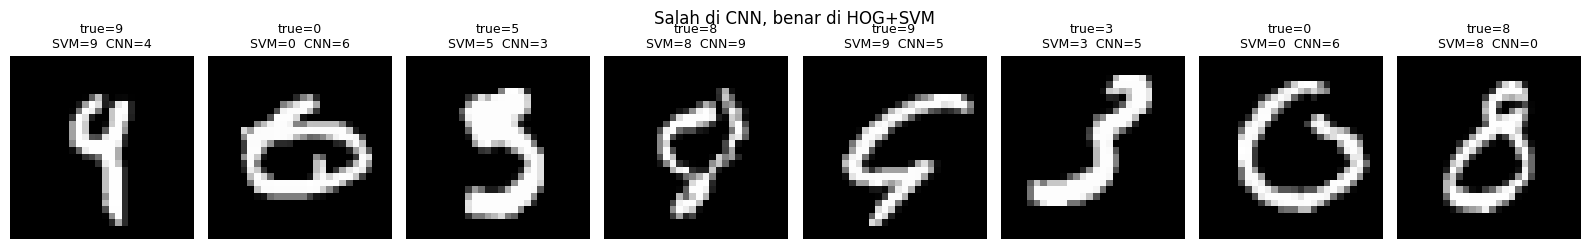

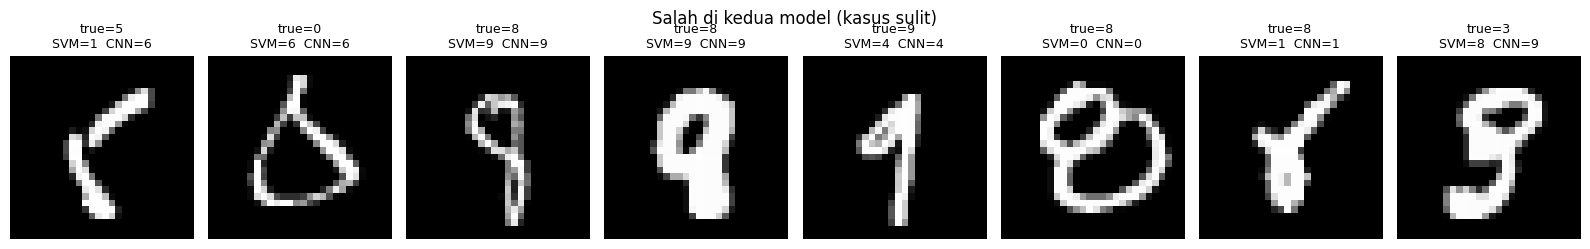

In [13]:
svm_ok = (results['HOG+SVM']['pred_val'] == y_val)
cnn_ok = (results['CNN']['pred_val']     == y_val)

wrong_svm_only = np.where(~svm_ok &  cnn_ok)[0]
wrong_cnn_only = np.where( svm_ok & ~cnn_ok)[0]
wrong_both     = np.where(~svm_ok & ~cnn_ok)[0]

print(f'salah hanya di HOG+SVM (CNN benar): {len(wrong_svm_only)}')
print(f'salah hanya di CNN (HOG+SVM benar): {len(wrong_cnn_only)}')
print(f'salah di kedua model              : {len(wrong_both)}')

def show_examples(idxs, title, n=8):
    if len(idxs) == 0:
        print(f'(tidak ada sampel untuk {title})'); return
    n = min(n, len(idxs))
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    if n == 1: axes = [axes]
    for ax, i in zip(axes, idxs[:n]):
        ax.imshow(X_val_img[i], cmap='gray')
        ax.set_title(f"true={y_val[i]}\nSVM={results['HOG+SVM']['pred_val'][i]}  CNN={results['CNN']['pred_val'][i]}",
                     fontsize=9)
        ax.axis('off')
    plt.suptitle(title); plt.tight_layout(); plt.show()

show_examples(wrong_svm_only, 'Salah di HOG+SVM, benar di CNN')
show_examples(wrong_cnn_only, 'Salah di CNN, benar di HOG+SVM')
show_examples(wrong_both,     'Salah di kedua model (kasus sulit)')

## 10. Submission Kaggle

Pakai model dengan val acc terbaik untuk prediksi pada `test.csv` Kaggle. Output: `submission_mnist.csv` dengan kolom `ImageId, Label`.

In [14]:
best_name = max(results, key=lambda k: results[k]['val'])
print(f'Model terbaik di val: {best_name}  (val acc={results[best_name]["val"]:.4f})')

# Predict pada Kaggle test
if best_name == 'HOG+SVM':
    pred_kaggle = results['HOG+SVM']['model'].predict(results['HOG+SVM']['hog_kaggle'])
elif best_name == 'PCA+KNN':
    pred_kaggle = results['PCA+KNN']['model'].predict(results['PCA+KNN']['pc_kaggle'])
else:  # CNN
    cnn.eval()
    with torch.no_grad():
        preds = []
        bs = 512
        for i in range(0, len(Xkg_t), bs):
            preds.append(cnn(Xkg_t[i:i+bs]).argmax(1).numpy())
        pred_kaggle = np.concatenate(preds)

submission = pd.DataFrame({
    'ImageId': np.arange(1, len(pred_kaggle)+1),
    'Label'  : pred_kaggle.astype(int)
})
submission.to_csv('submission_mnist.csv', index=False)
print(f'\nsubmission_mnist.csv : {submission.shape}')
print(submission.head())
print(f'\nDistribusi prediksi: {pd.Series(pred_kaggle).value_counts().sort_index().to_dict()}')

Model terbaik di val: CNN  (val acc=0.9890)



submission_mnist.csv : (28000, 2)
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3

Distribusi prediksi: {0: 2764, 1: 3226, 2: 2798, 3: 2773, 4: 2799, 5: 2486, 6: 2748, 7: 2914, 8: 2749, 9: 2743}


## 11. Diskusi & Kesimpulan

Ringkasan angka aktual:

| Model | Val Acc | Train Time | Infer Time (4200 val) |
|---|---|---|---|
| HOG + LinearSVM | 0.9676 | 14.04s | **0.004s** |
| PCA + KNN | 0.9674 | 0.50s | 0.171s |
| **CNN** | **0.9890** | 92.55s | 0.342s |

Pengamatan:

1. **CNN unggul jelas (~2.1% di atas HOG+SVM)** di val 4200 sampel. Di MNIST yang struktural, CNN memang seharusnya menang dengan margin nyata.
2. **HOG+SVM dan PCA+KNN praktis seri (0.9676 vs 0.9674)** — keduanya solid baseline klasik untuk image. Bukti bahwa fitur klasik yang dirancang khusus untuk image (gradient orientation atau reduksi dimensi statistik) masih sangat berguna.
3. **Plot twist di inference time**: HOG+LinearSVM sangat efisien (0.004s untuk 4200 sampel), ~85× lebih cepat dari CNN (0.342s). LinearSVM tinggal matrix multiply, sedangkan CNN harus forward pass beberapa layer konvolusi di CPU. KNN ada di tengah karena harus cari neighbor di 20k sampel store.
4. **Trade-off train time**: PCA+KNN praktis "free" (0.50s — KNN tidak benar-benar train), HOG+SVM ~14s, CNN 92s. CNN paling mahal tapi memberi akurasi terbaik.

**Pola error** (dari section 9):

- **110 sampel salah hanya di HOG+SVM (CNN benar)** — kemenangan CNN. CNN bisa generalisasi pola yang HOG (gradient histogram fixed) lewatkan, terutama di digit dengan stroke yang tidak biasa.
- **20 sampel salah hanya di CNN (HOG+SVM benar)** — sedikit, biasanya kasus dengan pola gradient yang sangat tegas yang HOG "baca" literal sementara CNN over-generalisasi.
- **26 sampel salah di kedua model** — kasus benar-benar sulit (stroke ambigu antara 4/9, 3/5, 7/2).

Net: CNN menang 90 sampel lebih banyak dari HOG+SVM. Ini menjelaskan gap akurasi 2.1%.

**Trade-off**:

| Aspek | Pemenang |
|---|---|
| Akurasi val | **CNN** (0.9890) |
| Train time | **PCA+KNN** (0.50s) — lazy learning |
| Infer time | **HOG+LinearSVM** (0.004s, ~85× lebih cepat dari CNN) |
| Robustness ke variasi | **CNN** (belajar fitur invarian via konvolusi) |
| Interpretabilitas | HOG bisa divisualisasi; CNN butuh Grad-CAM dll |
| Submission Kaggle | CNN dipakai (val acc tertinggi) — output di `submission_mnist.csv` |

**Kesimpulan**: untuk MNIST, **CNN adalah pilihan terbaik dari sisi akurasi** — gap 2.1% di val 4200 itu konsisten dengan ekspektasi karena data image punya struktur spasial yang ideal untuk konvolusi. Tapi classical (HOG+SVM, PCA+KNN) tidak hancur — masih di level 96%+ dengan biaya komputasi jauh lebih kecil. Pelajaran: pilih sesuai kebutuhan — kalau target akurasi tinggi, CNN; kalau latency-critical CPU, HOG+SVM mungkin lebih masuk akal.